# Evaluation Analysis for Recommender Output

In this section we will analyze and compare the generated recommendations and predictions from a predefined list of algorithms with the goal of assessing the performance of each algorithm with respect to a metric. In other words, we would rank the algorithms for each metric considered with respect to performance.

## Setup

Below are the list of packages required to successfully run the analysis. They are divided into partitions to signify their specific task.<br>
We need the pathlib package for working with files and folders

In [1]:
from pathlib import Path
import json

Load libraries for analysis and visualization:

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import the LensKit metrics for analysis:

In [3]:
from lenskit.data import Dataset, ItemListCollection
from lenskit.metrics import RunAnalysis, RMSE, NDCG, RecipRank, RBP

## Load Data

The recommendations are in `runs`, and we will need to reassemble the test data from `test`.

In [4]:
dataset = "ml-100k"

In [5]:
# Parameters
dataset = "ml-100k"


In [6]:
output_root = Path("runs")
run_dir = output_root / dataset

In [7]:
dirs = [rd for rd in run_dir.iterdir() if rd.is_dir()]

In [8]:
recs = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("recs-*"):
        rec = ItemListCollection.load_parquet(file)
        recs.add_from(rec, model=fld.name)

In [9]:
rec_algos = sorted(set(a for (a, _u) in recs.keys()))
rec_algos

['als-explicit',
 'als-implicit',
 'bias',
 'flex-bpr',
 'flex-explicit',
 'flex-logistic',
 'flex-warp',
 'iknn-explicit',
 'iknn-implicit',
 'lightgcn',
 'lightgcn-warp',
 'popular',
 'slim',
 'slim-fs',
 'uknn-explicit',
 'uknn-implicit']

In [10]:
preds = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("pred-*"):
        pred = ItemListCollection.load_parquet(file)
        preds.add_from(pred, model=fld.name)

We need to load the test data so that we have the ground truths for computing accuracy.

In [11]:
test = ItemListCollection.load_parquet(f"data-split/{dataset}/test.parquet")

## Top-N Metrics

`RunListAnalysis` computes metrics for recommendation results and takes care of
matching recommendations and ground truth.

In [12]:
ra = RunAnalysis()

ra.add_metric(NDCG())
ra.add_metric(RecipRank())
ra.add_metric(RBP())

rec_results = ra.compute(recs, test)
rec_results.list_summary('model')

/home/mde48/lenskit/lkpy/src/lenskit/metrics/bulk.py:95: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


mean    median       std
model                                                
als-explicit  NDCG       0.108053  0.065268  0.116701
              RBP        0.070876  0.001347  0.138695
              RecipRank  0.160821  0.033333  0.278002
als-implicit  NDCG       0.165977  0.139458  0.159443
              RBP        0.111934  0.027860  0.174600
              RecipRank  0.264035  0.083333  0.357029
bias          NDCG       0.107843  0.073623  0.115772
              RBP        0.074535  0.006072  0.119829
              RecipRank  0.142874  0.047619  0.222645
flex-bpr      NDCG       0.198304  0.154039  0.172357
              RBP        0.143063  0.038569  0.214937
              RecipRank  0.294879  0.100000  0.378203
flex-explicit NDCG       0.086119  0.071775  0.092519
              RBP        0.051046  0.000827  0.094744
              RecipRank  0.142154  0.030303  0.259767
flex-logistic NDCG       0.194293  0.151391  0.188340
              RBP        0.126598  0.041739  0.193173
              RecipRank  0.283136  0.100000  0.375147
flex-warp     NDCG       0.194269  0.155001  0.171612
              RBP        0.136303  0.034743  0.207930
              RecipRank  0.285992  0.083333  0.373848
iknn-explicit NDCG       0.077086  0.052108  0.086390
              RBP        0.039279  0.000597  0.086766
              RecipRank  0.100569  0.028571  0.207027
iknn-implicit NDCG       0.141562  0.056313  0.176943
              RBP        0.125543  0.000163  0.229975
              RecipRank  0.214282  0.023256  0.345810
lightgcn      NDCG       0.199422  0.145452  0.187863
              RBP        0.139987  0.046357  0.209208
              RecipRank  0.287941  0.100000  0.380061
lightgcn-warp NDCG       0.194570  0.152006  0.174313
              RBP        0.138326  0.041241  0.208589
              RecipRank  0.284367  0.090909  0.379225
popular       NDCG       0.194559  0.161316  0.179668
              RBP        0.131380  0.040874  0.191536
              RecipRank  0.262258  0.111111  0.340544
slim          NDCG       0.198184  0.179721  0.167212
              RBP        0.139435  0.069591  0.199446
              RecipRank  0.287511  0.125000  0.353584
slim-fs       NDCG       0.199155  0.184438  0.170304
              RBP        0.139468  0.066563  0.201936
              RecipRank  0.285362  0.111111  0.361355
uknn-explicit NDCG       0.078296  0.066071  0.072330
              RBP        0.020274  0.000713  0.043821
              RecipRank  0.050235  0.029412  0.076343
uknn-implicit NDCG       0.183280  0.125354  0.195332
              RBP        0.128414  0.024907  0.208380
              RecipRank  0.265198  0.071429  0.367912

We can reshape the list metrics and plot them:

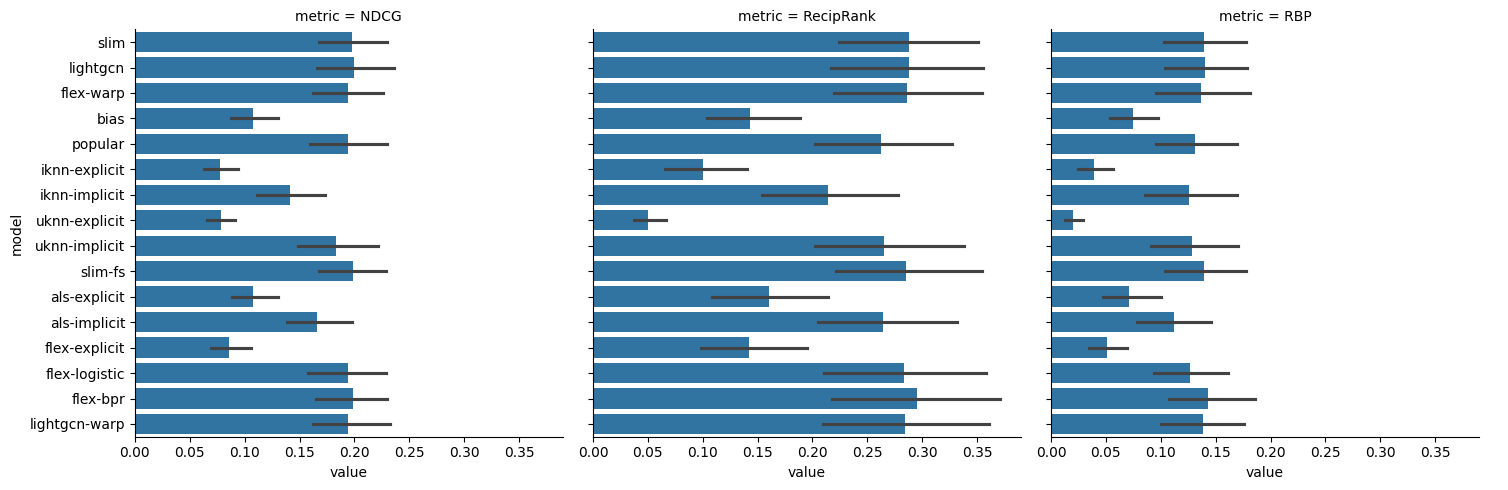

In [13]:
metrics = rec_results.list_metrics()
metrics = metrics.melt(var_name='metric', ignore_index=False).reset_index()
sns.catplot(metrics, y='model', x='value', col='metric', kind='bar')
plt.show()

## Prediction RMSE

We will also look at the prediction RMSE.

In [14]:
pa = RunAnalysis()

pa.add_metric(RMSE(missing_scores='ignore', missing_truth='ignore'))

pred_results = pa.compute(preds, test)
pred_results.list_summary('model')

/home/mde48/lenskit/lkpy/src/lenskit/metrics/bulk.py:95: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,,mean,median,std
model,,,,
als-explicit,RMSE,0.858624,0.842527,0.360905
bias,RMSE,0.875318,0.851510,0.353092
flex-explicit,RMSE,0.941308,0.954304,0.402611
iknn-explicit,RMSE,0.867329,0.860759,0.370899
uknn-explicit,RMSE,0.881776,0.863499,0.379490


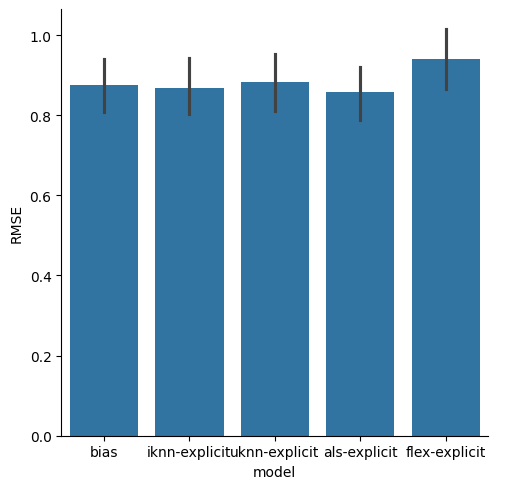

In [15]:
pred_metrics = pred_results.list_metrics().reset_index()
sns.catplot(pred_metrics, x='model', y='RMSE', kind='bar')
plt.show()

## Save Metrics

We'll now save the metrics to a file.

In [16]:
rlsum = rec_results.list_summary('model')['mean'].unstack()
rlsum

/home/mde48/lenskit/lkpy/src/lenskit/metrics/bulk.py:95: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,NDCG,RBP,RecipRank
model,,,
als-explicit,0.108053,0.070876,0.160821
als-implicit,0.165977,0.111934,0.264035
bias,0.107843,0.074535,0.142874
flex-bpr,0.198304,0.143063,0.294879
flex-explicit,0.086119,0.051046,0.142154
flex-logistic,0.194293,0.126598,0.283136
flex-warp,0.194269,0.136303,0.285992
iknn-explicit,0.077086,0.039279,0.100569
iknn-implicit,0.141562,0.125543,0.214282


In [17]:
rlsum.to_json(f'eval-metrics.{dataset}.json', orient='index')